# Exploration des données ICE Detention Dataset
**Source** : Dataset public sur les détentions ICE (Immigration and Customs Enforcement) — USA  
**Objectif** : Explorer, nettoyer et préparer les données avant ingestion dans Azure SQL Database via ADF.

## 0. Imports & configuration

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/raw/detention-stays-latest.csv'

## 1. Chargement et première visualisation

In [22]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print(f'Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df.head(5)

Shape : 671750 lignes x 45 colonnes
Taille mémoire : 1594.37 MB


,stay_ID,n_stints,detention_facility_codes_all,stay_book_in_date_time,stay_book_out_date_time,detention_release_reason,stay_book_out_date,stay_release_reason,religion,gender,marital_status,birth_year,ethnicity,entry_status,felon,bond_posted_date,bond_posted_amount,case_status,case_category,final_order_yes_no,final_order_date,case_threat_level,book_in_criminality,final_charge,departed_date,departure_country,initial_bond_set_amount,citizenship_country,final_program,most_serious_conviction_code,msc_charge,unique_identifier,n_stays,detention_facility_first,detention_facility_code_first,book_in_date_time_first,book_out_date_time_first,detention_facility_longest,detention_facility_code_longest,book_in_date_time_longest,book_out_date_time_longest,detention_facility_last,detention_facility_code_last,book_in_date_time_last,book_out_date_time_last
0,000033bd6a1712721982e3cc31fa5efe203aa033_2025-...,3,KRO; WCCPBFL; JENATLA,2025-05-19 22:35:00 UTC,2025-06-02 07:02:00 UTC,Removed,2025-06-02,Removed,NaN,Male,NaN,1987,NaN,PWA Mexico,NaN,NaN,NaN,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,YES,2025-05-23,NaN,2 Pending Criminal Charges,ALIEN PRESENT WITHOUT ADMISSION OR PAROLE - (P...,2025-06-02,HONDURAS,NaN,HONDURAS,Border Patrol,NaN,NaN,000033bd6a1712721982e3cc31fa5efe203aa033,1,KROME NORTH SPC,KRO,2025-05-19 22:35:00 UTC,2025-05-20 19:30:00 UTC,BROWARD TRANSITIONAL CENTER,WCCPBFL,2025-05-20 21:23:00 UTC,2025-05-31 06:30:00 UTC,ALEXANDRIA STAGING FACILITY,JENATLA,2025-06-01 00:05:00 UTC,2025-06-02 07:02:00 UTC
1,00007cb10d7edd5e97cbefad22016c1679d98343_2023-...,2,ALAMCNC; STWRTGA,2023-09-23 12:00:00 UTC,2023-11-27 14:56:00 UTC,Removed,2023-11-27,Removed,NaN,Male,Married,1963,Hispanic Origin,Not Applicable,Not an Aggravated Felon,NaN,NaN,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,YES,2023-10-16,1.00,1 Convicted Criminal,ALIEN PRESENT WITHOUT ADMISSION OR PAROLE - (P...,2023-11-27,MEXICO,NaN,MEXICO,ERO Criminal Alien Program,35AB,Drug Trafficking,00007cb10d7edd5e97cbefad22016c1679d98343,1,ALAMANCE CO. DET. FACILITY,ALAMCNC,2023-09-23 12:00:00 UTC,2023-09-25 06:24:00 UTC,STEWART DETENTION CENTER,STWRTGA,2023-09-25 14:35:00 UTC,2023-11-27 14:56:00 UTC,STEWART DETENTION CENTER,STWRTGA,2023-09-25 14:35:00 UTC,2023-11-27 14:56:00 UTC
2,000086ed0144f7adc8cf34591b321db280497912_2024-...,2,MTGPCTX; PINEPLA,2024-02-10 11:08:00 UTC,2024-04-05 11:02:00 UTC,Removed,2024-04-05,Removed,NaN,Male,NaN,1966,NaN,PWA Mexico,Not an Aggravated Felon,NaN,NaN,6-Deported/Removed - Deportability,[16] Reinstated Final Order,YES,2024-02-09,NaN,3 Other Immigration Violator,"ALIEN PREVIOUSLY REMOVED ONCE, AS AN ARRIVING ...",2024-04-05,EL SALVADOR,NaN,EL SALVADOR,Border Patrol,NaN,NaN,000086ed0144f7adc8cf34591b321db280497912,1,MONTGOMERY PROCESSING CTR,MTGPCTX,2024-02-10 11:08:00 UTC,2024-03-29 12:00:00 UTC,MONTGOMERY PROCESSING CTR,MTGPCTX,2024-02-10 11:08:00 UTC,2024-03-29 12:00:00 UTC,PINE PRAIRIE ICE PROCESSING CENTER,PINEPLA,2024-03-29 13:54:00 UTC,2024-04-05 11:02:00 UTC
3,00008df187d556536d9799c5a3e889cbca52ae48_2023-...,4,SFRHOLD; GLDSACA; BKLHOLD; STCDFTX,2023-11-09 11:31:00 UTC,2023-12-18 16:46:00 UTC,Removed,2023-12-18,Removed,NaN,Male,Single,1996,Hispanic Origin,Not Applicable,Not an Aggravated Felon,NaN,NaN,8-Excluded/Removed - Inadmissibility,[16] Reinstated Final Order,YES,2017-03-08,3.00,1 Convicted Criminal,PREVIOUSLY ORDERED REMOVED AND ENTERED OR ATTE...,2023-12-18,HONDURAS,NaN,HONDURAS,ERO Criminal Alien Program,3599,Dangerous Drugs,00008df187d556536d9799c5a3e889cbca52ae48,2,SFR HOLD ROOM,SFRHOLD,2023-11-09 11:31:00 UTC,2023-11-09 14:24:00 UTC,GOLDEN STATE ANNEX,GLDSACA,2023-11-09 22:00:00 UTC,2023-12-05 05:30:00 UTC,SOUTH TEXAS ICE PROCESSING CENTER,STCDFTX,2023-12-06 20:49:00 UTC,2023-12-18 16:46:00 UTC
4,00008df187d556536d9799c5a3e889cbca52ae48_2025-...,3,SFRHOLD; GLDSACA; EROFCB,2025-09-11 11:10:00 UTC,2025-09-16 04:30:00 UTC,Removed,2025-09-16,Removed,NaN,Male,Sin

In [23]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 671750 entries, 0 to 671749
Data columns (total 45 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   stay_ID                          671750 non-null  str    
 1   n_stints                         671750 non-null  int64  
 2   detention_facility_codes_all     671750 non-null  str    
 3   stay_book_in_date_time           671750 non-null  str    
 4   stay_book_out_date_time          609849 non-null  str    
 5   detention_release_reason         610132 non-null  str    
 6   stay_book_out_date               609849 non-null  str    
 7   stay_release_reason              609851 non-null  str    
 8   religion                         14041 non-null   str    
 9   gender                           671750 non-null  str    
 10  marital_status                   520629 non-null  str    
 11  birth_year                       671750 non-null  int64  
 12  ethnicity    

In [24]:
df.describe()

,n_stints,birth_year,bond_posted_amount,case_threat_level,initial_bond_set_amount,n_stays
count,671750.00,671750.00,43609.00,200083.00,45406.00,671750.00
mean,2.39,1990.97,6969.51,1.92,7190.80,1.11
std,1.55,10.64,5368.56,0.87,10849.86,0.35
min,1.00,1930.00,50.00,1.00,0.00,1.00
25%,1.00,1984.00,3500.00,1.00,3500.00,1.00
50%,2.00,1992.00,5000.00,2.00,5000.00,1.00
75%,3.00,1999.00,10000.00,3.00,10000.00,1.00
max,73.00,2025.00,150000.00,3.00,999999.00,7.00


## 2. Analyse de la structure métier

In [25]:
n_stays   = df['stay_ID'].nunique()
n_persons = df['unique_identifier'].nunique()
print(f'Séjours uniques     : {n_stays:,}')
print(f'Individus uniques   : {n_persons:,}')
print(f'Séjours / individu  : {n_stays/n_persons:.2f} en moyenne')

stays_per_person = df.groupby('unique_identifier')['stay_ID'].count()
print(f'\nMax séjours pour un individu : {stays_per_person.max()}')
stays_per_person.value_counts().sort_index().head(10)

Séjours uniques     : 671,750
Individus uniques   : 637,020
Séjours / individu  : 1.05 en moyenne

Max séjours pour un individu : 7


stay_ID
1    604472
2     30531
3      1874
4       125
5        15
6         2
7         1
Name: count, dtype: int64

Distribution n_stints (centres par séjour) :
n_stints
1     243850
2     173607
3     123214
4      69288
5      33977
6      14726
7       6445
8       3153
9       1545
10       890
11       443
12       244
13       156
14        70
15        46
16        30
17        23
18        10
19        11
20         7
21         4
22         2
23         1
24         1
25         2
26         1
29         1
30         1
41         1
73         1
Name: count, dtype: int64


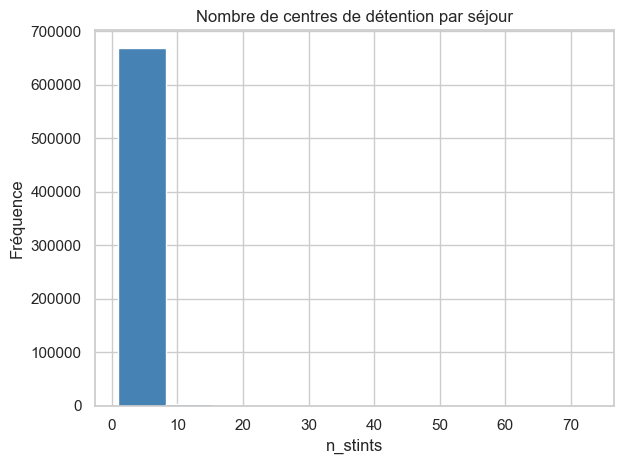

In [26]:
print('Distribution n_stints (centres par séjour) :')
print(df['n_stints'].value_counts().sort_index())

df['n_stints'].hist(bins=10, color='steelblue', edgecolor='white')
plt.title('Nombre de centres de détention par séjour')
plt.xlabel('n_stints')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

## 3. Valeurs manquantes

                              Valeurs manquantes  Pourcentage (%)
religion                                  657709            97.91
bond_posted_date                          628141            93.51
bond_posted_amount                        628141            93.51
initial_bond_set_amount                   626344            93.24
most_serious_conviction_code              471669            70.21
msc_charge                                471669            70.21
case_threat_level                         471667            70.21
ethnicity                                 400361            59.60
felon                                     377489            56.19
final_charge                              243617            36.27
departure_country                         243372            36.23
departed_date                             243267            36.21
final_order_date                          240153            35.75
marital_status                            151121            22.50
stay_book_

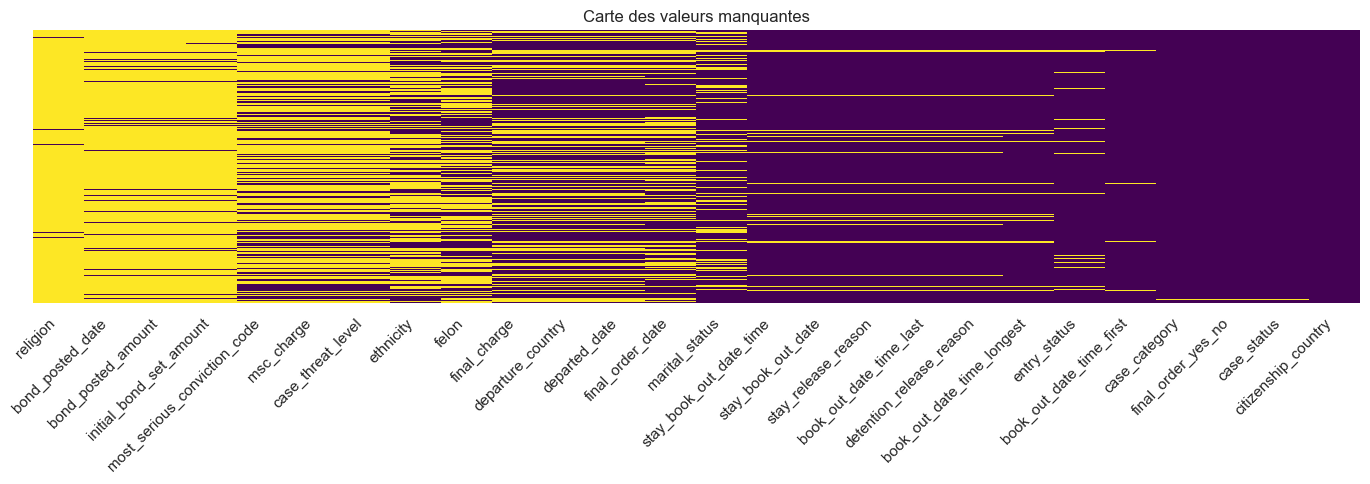

In [27]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).sort_values('Pourcentage (%)', ascending=False)

print(missing_df[missing_df['Valeurs manquantes'] > 0].to_string())

cols_with_na = missing_df[missing_df['Valeurs manquantes'] > 0].index.tolist()
if cols_with_na:
    plt.figure(figsize=(14, 5))
    sns.heatmap(df[cols_with_na].isnull(), cbar=False,
                yticklabels=False, cmap='viridis')
    plt.title('Carte des valeurs manquantes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Données aberrantes — birth_year

Statistiques birth_year :
count   671750.00
mean      1990.97
std         10.64
min       1930.00
25%       1984.00
50%       1992.00
75%       1999.00
max       2025.00
Name: birth_year, dtype: float64

Valeurs aberrantes : 9266


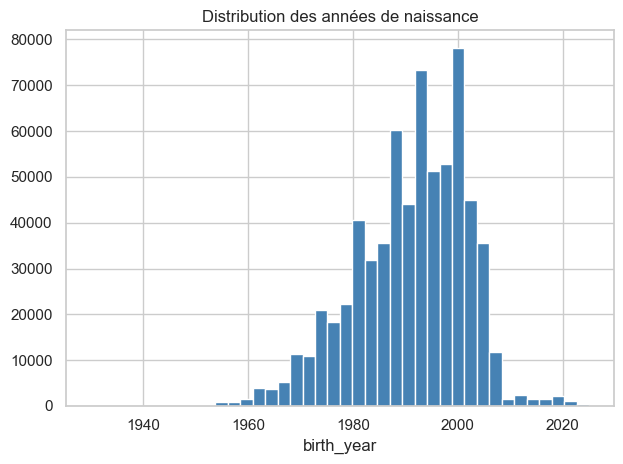

In [28]:
print('Statistiques birth_year :')
print(df['birth_year'].describe())

mask_invalid = (df['birth_year'] < 1900) | (df['birth_year'] > 2010)
print(f'\nValeurs aberrantes : {mask_invalid.sum()}')

df['birth_year'].dropna().hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution des années de naissance')
plt.xlabel('birth_year')
plt.tight_layout()
plt.show()

## 5. Durée de détention

Durée de détention (jours) :
count   609849.00
mean        48.10
std         71.40
min          0.00
25%          8.56
50%         27.93
75%         58.43
max       7354.00
Name: detention_days, dtype: float64

Durées négatives : 0
Durées > 1095j   : 99


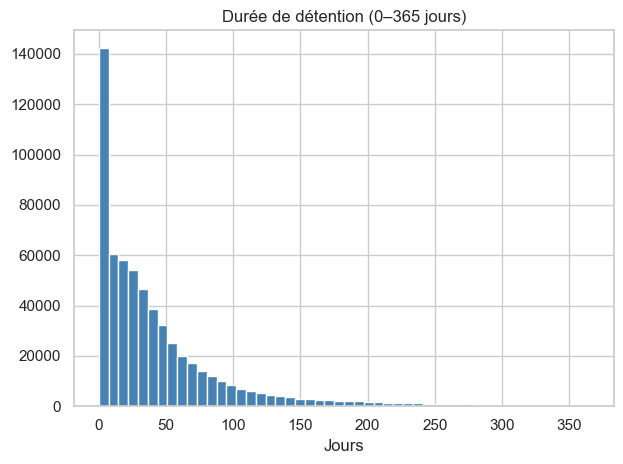

In [29]:
df['stay_book_in_date_time']  = pd.to_datetime(df['stay_book_in_date_time'],  errors='coerce', utc=True)
df['stay_book_out_date_time'] = pd.to_datetime(df['stay_book_out_date_time'], errors='coerce', utc=True)

df['detention_days'] = (
    df['stay_book_out_date_time'] - df['stay_book_in_date_time']
).dt.total_seconds() / 86400

print('Durée de détention (jours) :')
print(df['detention_days'].describe())
print(f"\nDurées négatives : {(df['detention_days'] < 0).sum()}")
print(f"Durées > 1095j   : {(df['detention_days'] > 1095).sum()}")

df[df['detention_days'].between(0, 365)]['detention_days'].hist(
    bins=50, color='steelblue', edgecolor='white')
plt.title('Durée de détention (0–365 jours)')
plt.xlabel('Jours')
plt.tight_layout()
plt.show()

## 6. Analyses démographiques et géographiques

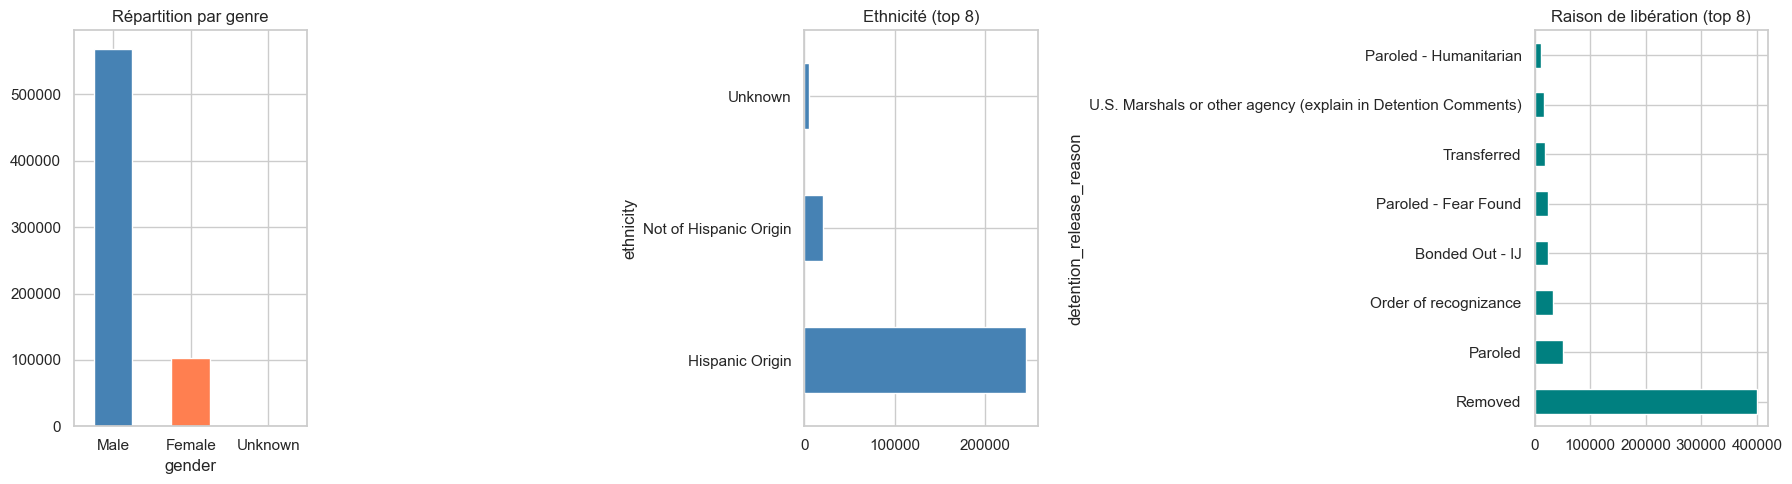

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['gender'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue','coral','gray'], edgecolor='white')
axes[0].set_title('Répartition par genre')
axes[0].tick_params(axis='x', rotation=0)

df['ethnicity'].value_counts().head(8).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Ethnicité (top 8)')

df['detention_release_reason'].value_counts().head(8).plot(
    kind='barh', ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('Raison de libération (top 8)')

plt.tight_layout()
plt.show()

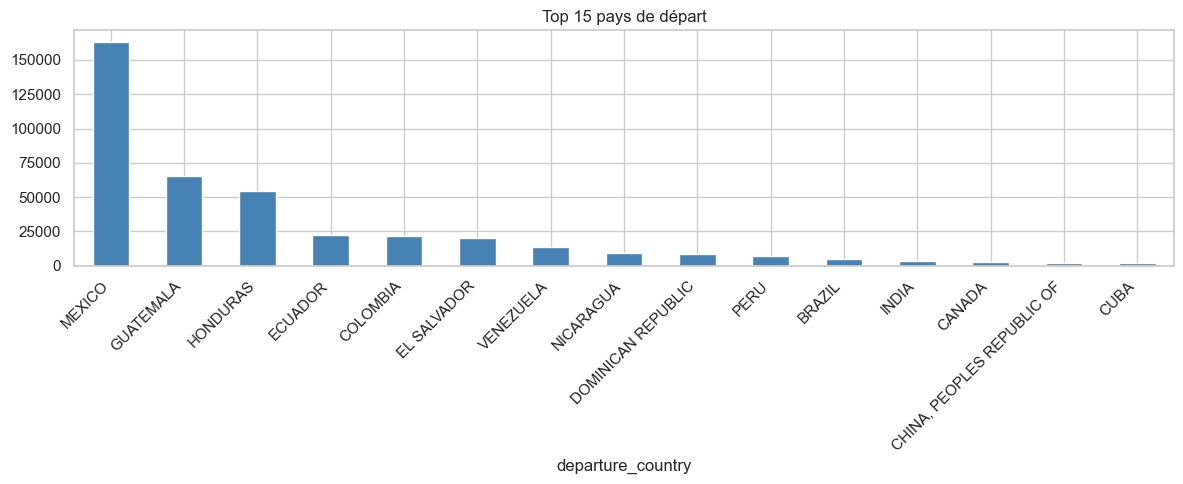

In [31]:
# Top 15 pays de départ
df['departure_country'].value_counts().head(15).plot(
    kind='bar', color='steelblue', edgecolor='white', figsize=(12, 5))
plt.title('Top 15 pays de départ')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

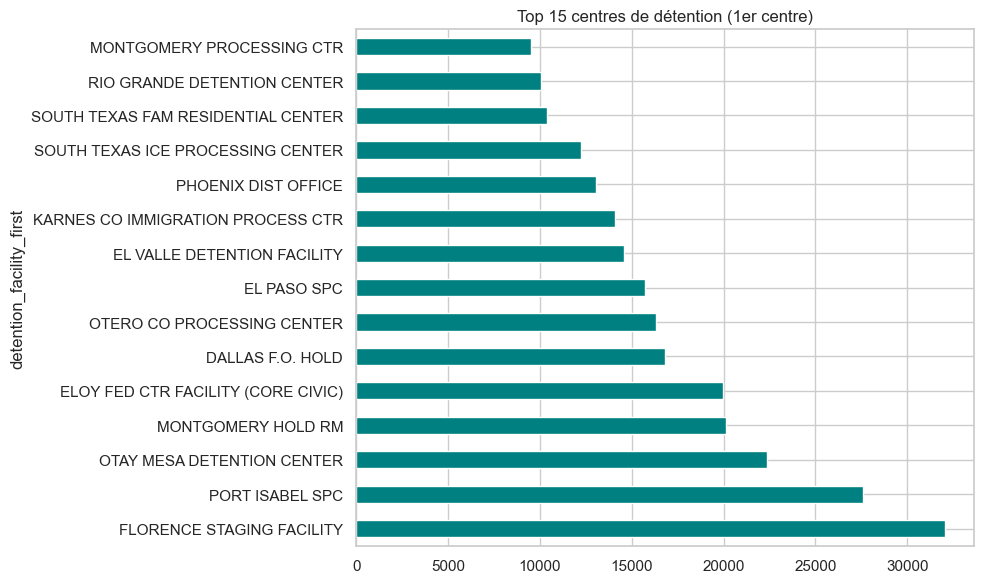

In [32]:
# Top 15 centres de détention
df['detention_facility_first'].value_counts().head(15).plot(
    kind='barh', color='teal', edgecolor='white', figsize=(10, 6))
plt.title('Top 15 centres de détention (1er centre)')
plt.tight_layout()
plt.show()

## 7. Évolution temporelle

/var/folders/md/4rs9bt3j75v_7l8jy1gdf6m80000gn/T/ipykernel_11153/5618758.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['book_in_month'] = df['stay_book_in_date_time'].dt.to_period('M')


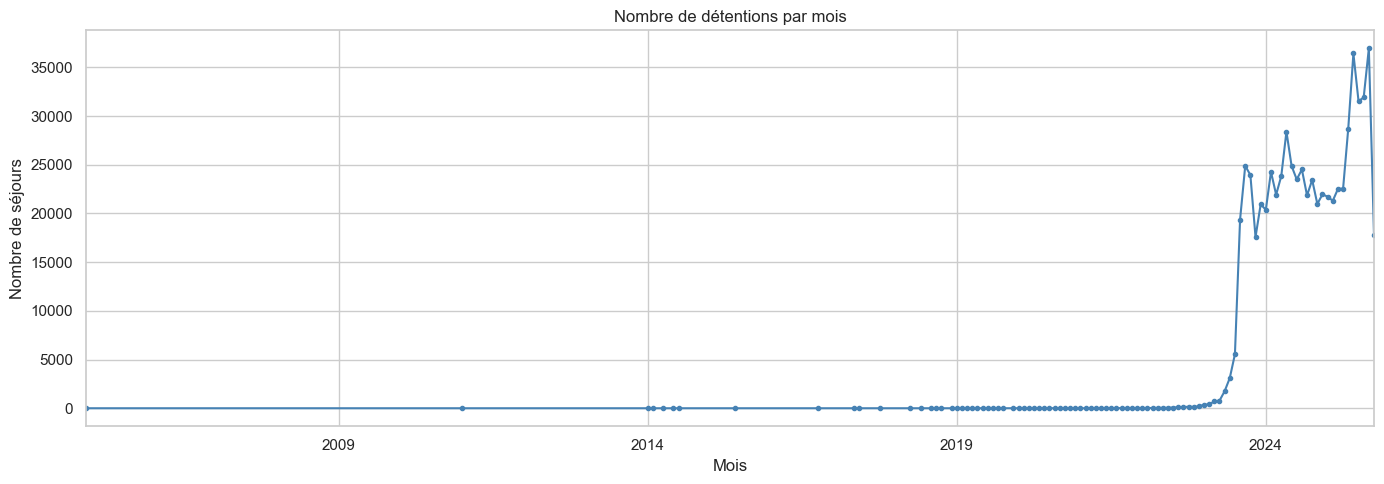

In [33]:
df['book_in_month'] = df['stay_book_in_date_time'].dt.to_period('M')
monthly = df.groupby('book_in_month').size()

monthly.plot(kind='line', figsize=(14, 5), color='steelblue', marker='o', markersize=3)
plt.title('Nombre de détentions par mois')
plt.xlabel('Mois')
plt.ylabel('Nombre de séjours')
plt.tight_layout()
plt.show()

## 8. Doublons

In [34]:
print(f"Doublons sur stay_ID          : {df.duplicated(subset=['stay_ID']).sum()}")
print(f"Lignes entièrement dupliquées : {df.duplicated().sum()}")

Doublons sur stay_ID          : 0
Lignes entièrement dupliquées : 0


## 9. Nettoyage & standardisation

In [35]:
df_clean = df.copy()

# 9.1 Doublons
df_clean = df_clean.drop_duplicates(subset=['stay_ID'])
print(f'Après suppression doublons       : {df_clean.shape}')

# 9.2 birth_year aberrant
df_clean.loc[
    (df_clean['birth_year'] < 1900) | (df_clean['birth_year'] > 2010),
    'birth_year'
] = np.nan

# 9.3 Durées négatives
df_clean = df_clean[df_clean['detention_days'] >= 0]
print(f'Après suppression durées négatives : {df_clean.shape}')

# 9.4 NaN texte -> Unknown
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna('Unknown')

# 9.5 Noms colonnes en snake_case
df_clean.columns = (
    df_clean.columns
    .str.strip().str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

# 9.6 Sélection colonnes pertinentes pour Azure SQL
COLS_KEEP = [
    'stay_id', 'n_stints', 'stay_book_in_date_time', 'stay_book_out_date_time',
    'detention_release_reason', 'stay_release_reason',
    'gender', 'marital_status', 'birth_year', 'ethnicity',
    'entry_status', 'felon', 'case_status', 'case_category',
    'final_order_yesno', 'case_threat_level', 'book_in_criminality',
    'departure_country', 'citizenship_country', 'final_program',
    'msc_charge', 'unique_identifier', 'n_stays',
    'detention_facility_first', 'detention_facility_last',
    'detention_days'
]
COLS_KEEP = [c for c in COLS_KEEP if c in df_clean.columns]
df_clean = df_clean[COLS_KEEP]

print(f'\nShape finale                     : {df_clean.shape}')
print(f'Valeurs manquantes restantes     : {df_clean.isnull().sum().sum()}')
df_clean.head()

Après suppression doublons       : (671750, 47)
Après suppression durées négatives : (609849, 47)


/var/folders/md/4rs9bt3j75v_7l8jy1gdf6m80000gn/T/ipykernel_11153/1856855786.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include='object').columns:



Shape finale                     : (609849, 25)
Valeurs manquantes restantes     : 435094


,stay_id,n_stints,stay_book_in_date_time,stay_book_out_date_time,detention_release_reason,stay_release_reason,gender,marital_status,birth_year,ethnicity,entry_status,felon,case_status,case_category,case_threat_level,book_in_criminality,departure_country,citizenship_country,final_program,msc_charge,unique_identifier,n_stays,detention_facility_first,detention_facility_last,detention_days
0,000033bd6a1712721982e3cc31fa5efe203aa033_2025-...,3,2025-05-19 22:35:00+00:00,2025-06-02 07:02:00+00:00,Removed,Removed,Male,Unknown,1987.00,Unknown,PWA Mexico,Unknown,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,NaN,2 Pending Criminal Charges,HONDURAS,HONDURAS,Border Patrol,Unknown,000033bd6a1712721982e3cc31fa5efe203aa033,1,KROME NORTH SPC,ALEXANDRIA STAGING FACILITY,13.35
1,00007cb10d7edd5e97cbefad22016c1679d98343_2023-...,2,2023-09-23 12:00:00+00:00,2023-11-27 14:56:00+00:00,Removed,Removed,Male,Married,1963.00,Hispanic Origin,Not Applicable,Not an Aggravated Felon,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,1.00,1 Convicted Criminal,MEXICO,MEXICO,ERO Criminal Alien Program,Drug Trafficking,00007cb10d7edd5e97cbefad22016c1679d98343,1,ALAMANCE CO. DET. FACILITY,STEWART DETENTION CENTER,65.12
2,000086ed0144f7adc8cf34591b321db280497912_2024-...,2,2024-02-10 11:08:00+00:00,2024-04-05 11:02:00+00:00,Removed,Removed,Male,Unknown,1966.00,Unknown,PWA Mexico,Not an Aggravated Felon,6-Deported/Removed - Deportability,[16] Reinstated Final Order,NaN,3 Other Immigration Violator,EL SALVADOR,EL SALVADOR,Border Patrol,Unknown,000086ed0144f7adc8cf34591b321db280497912,1,MONTGOMERY PROCESSING CTR,PINE PRAIRIE ICE PROCESSING CENTER,55.00
3,00008df187d556536d9799c5a3e889cbca52ae48_2023-...,4,2023-11-09 11:31:00+00:00,2023-12-18 16:46:00+00:00,Removed,Removed,Male,Single,1996.00,Hispanic Origin,Not Applicable,Not an Aggravated Felon,8-Excluded/Removed - Inadmissibility,[16] Reinstated Final Order,3.00,1 Convicted Criminal,HONDURAS,HONDURAS,ERO Criminal Alien Program,Dangerous Drugs,00008df187d556536d9799c5a3e889cbca52ae48,2,SFR HOLD ROOM,SOUTH TEXAS ICE PROCESSING CENTER,39.22
4,00008df187d556536d9799c5a3e889cbca52ae48_2025-...,3,2025-09-11 11:10:00+00:00,2025-09-16 04:30:00+00:00,Removed,Removed,Male,Single,1996.00,Hispanic Origin,Not Applicable,Not an Aggravated Felon,8-Excluded/Removed - Inadmissibility,[16] Reinstated Final Order,3.00,1 Convicted Criminal,HONDURAS,HONDURAS,ERO Criminal Alien Program,Dangerous Drugs,00008df187d556536d9799c5a3e889cbca52ae48,2,SFR HOLD ROOM,ERO EL PASO CAMP EAST MONTANA,4.72


## 10. Export du dataset nettoyé

In [36]:
output_path = '../data/processed/ice_detentions_clean.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_clean.to_csv(output_path, index=False)

print(f'Fichier sauvegardé : {output_path}')
print(f'Shape : {df_clean.shape}')

Fichier sauvegardé : ../data/processed/ice_detentions_clean.csv
Shape : (609849, 25)


In [37]:
DATA_PATH_CLEAN = '../data/processed/ice_detentions_clean.csv'

df_final = pd.read_csv(DATA_PATH_CLEAN)
print(f'Shape du fichier final : {df_final.shape}')
df_final.head()
df_final.info(verbose=True, show_counts=True)
df_final.describe()

Shape du fichier final : (609849, 25)
<class 'pandas.DataFrame'>
RangeIndex: 609849 entries, 0 to 609848
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   stay_id                   609849 non-null  str    
 1   n_stints                  609849 non-null  int64  
 2   stay_book_in_date_time    609849 non-null  str    
 3   stay_book_out_date_time   609849 non-null  str    
 4   detention_release_reason  609849 non-null  str    
 5   stay_release_reason       609849 non-null  str    
 6   gender                    609849 non-null  str    
 7   marital_status            609849 non-null  str    
 8   birth_year                600883 non-null  float64
 9   ethnicity                 609849 non-null  str    
 10  entry_status              609849 non-null  str    
 11  felon                     609849 non-null  str    
 12  case_status               609849 non-null  str    
 13  case_category    

,n_stints,birth_year,case_threat_level,n_stays,detention_days
count,609849.00,600883.00,183721.00,609849.00,609849.00
mean,2.36,1990.76,1.92,1.12,48.10
std,1.55,10.20,0.87,0.36,71.40
min,1.00,1930.00,1.00,1.00,0.00
25%,1.00,1984.00,1.00,1.00,8.56
50%,2.00,1992.00,2.00,1.00,27.93
75%,3.00,1999.00,3.00,1.00,58.43
max,73.00,2010.00,3.00,7.00,7354.00
